<a href="https://colab.research.google.com/github/tozdty/mse-3021-cpa-dsc-data/blob/main/CPA_DSC_Plots.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CPA DSC Analysis — Crosslinked Polyethylene (L200 XLPE) & Polystyrene Insulation Foam
**Center for Puppetry Arts | Discovery DSC | Run Date: 4/22/2026**

| Sample | Material | Name | Description |
|--------|----------|------|-------------|
| Black Foam | Crosslinked Polyethylene | L200 | Black Dense Foam |
| Purple Foam | Polystyrene | Insulation Foam | Purple Dense Foam |

**Sign convention** (exo up): Exothermic events are positive ↑ (heat flows out of the sample); endothermic events are negative ↓ (heat flows into the sample).

### Before running
Upload `Black_foam.txt` and `Purple_foam.txt` to the Colab file browser (folder icon on the left sidebar), then run all cells.

##File Import

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import numpy as np
from scipy.signal import savgol_filter
from scipy.integrate import trapezoid

# ── Segment definitions ──────────────────────────────────────────────────────
SEGMENT_INFO = [
    ('Heat 1 (−25 → 280 °C)',   'heating'),
    ('Isothermal at 280 °C',    'isothermal'),
    ('Cool 1 (280 → −25 °C)',   'cooling'),
    ('Isothermal at −25 °C',    'isothermal'),
    ('Heat 2 (−25 → 280 °C)',   'heating'),
    ('Isothermal at 280 °C',    'isothermal'),
    ('Cool 2 (280 → −25 °C)',   'cooling'),
]
heat1='#E63946'
isotherm1='#999999'
cool1='#457B9D'
isotherm2='#AAAAAA'
heat2='#F4A261'
isotherm3='#BBBBBB'
cool2='#2A9D8F'

SEG_COLORS = [heat1,isotherm1,cool1,isotherm2,heat2,isotherm3, cool2]


# ── Parser ───────────────────────────────────────────────────────────────────
def parse_dsc(filepath):
    segments = []
    current  = None
    seg_idx  = -1
    state    = 'meta'

    with open(filepath, 'r', encoding='utf-8', errors='replace') as f:
        for line in f:
            line = line.strip()
            if state == 'meta':
                if line == '[step]':
                    state = 'name'
            elif state == 'name':
                seg_idx += 1
                label, direction = SEGMENT_INFO[seg_idx] if seg_idx < len(SEGMENT_INFO) else (line, 'unknown')
                current = {'label': label, 'direction': direction, 'rows': []}
                state = 'header'
            elif state == 'header':
                state = 'units'
            elif state == 'units':
                state = 'data'
            elif state == 'data':
                if line == '[step]':
                    segments.append(current)
                    state = 'name'
                else:
                    parts = line.split('\t')
                    if len(parts) == 3:
                        try:
                            current['rows'].append((float(parts[0]), float(parts[1]), float(parts[2])))
                        except ValueError:
                            pass

    if current and current['rows']:
        segments.append(current)

    for s in segments:
        s['df'] = pd.DataFrame(s.pop('rows'), columns=['Time_min', 'Temp_C', 'HeatFlow_W_g'])

    return segments

segs_black  = parse_dsc('Black_foam.txt')
segs_purple = parse_dsc('Purple_foam.txt')

print('Black foam:')
for s in segs_black:
    print(f"  {s['label']:35s} {len(s['df'])} rows")
print('\nPurple foam:')
for s in segs_purple:
    print(f"  {s['label']:35s} {len(s['df'])} rows")

Black foam:
  Heat 1 (−25 → 280 °C)               9152 rows
  Isothermal at 280 °C                302 rows
  Cool 1 (280 → −25 °C)               9164 rows
  Isothermal at −25 °C                302 rows
  Heat 2 (−25 → 280 °C)               9152 rows
  Isothermal at 280 °C                302 rows
  Cool 2 (280 → −25 °C)               9128 rows

Purple foam:
  Heat 1 (−25 → 280 °C)               9152 rows
  Isothermal at 280 °C                302 rows
  Cool 1 (280 → −25 °C)               9164 rows
  Isothermal at −25 °C                303 rows
  Heat 2 (−25 → 280 °C)               9152 rows
  Isothermal at 280 °C                302 rows
  Cool 2 (280 → −25 °C)               9129 rows


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Individual Sample Plots — All Segments

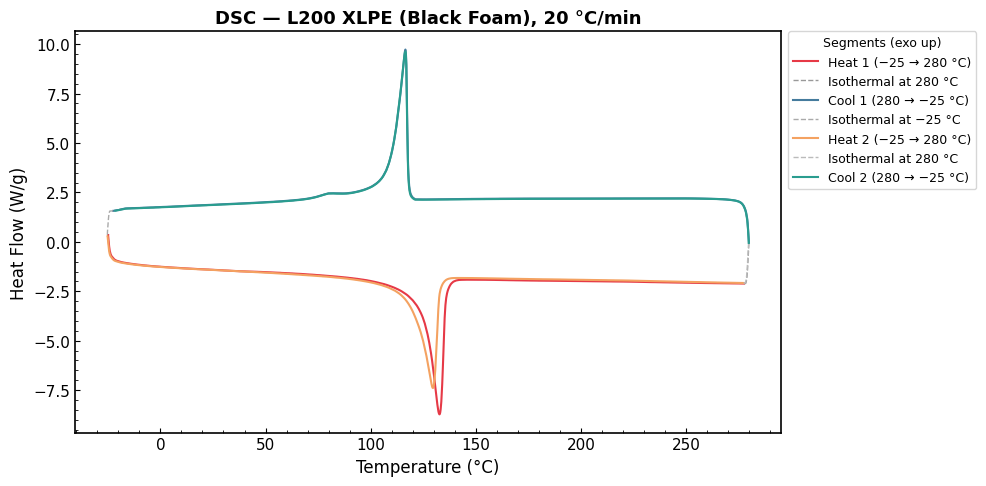

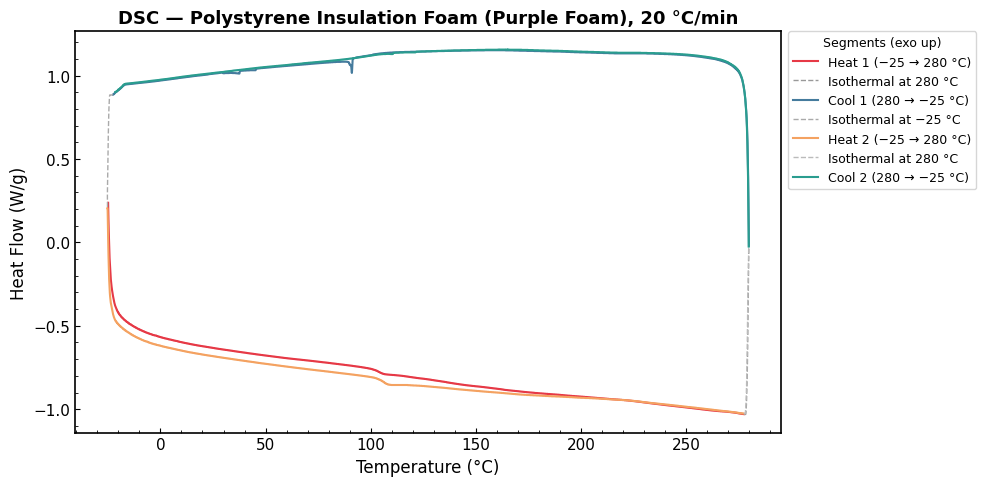

In [ ]:
plt.rcParams.update({'font.size': 11, 'axes.linewidth': 1.2,
                     'xtick.direction': 'in', 'ytick.direction': 'in'})

def plot_dsc(segments, title, filename):
    fig, ax = plt.subplots(figsize=(10, 5))

    for i, seg in enumerate(segments):
        df = seg['df'].dropna(subset=['HeatFlow_W_g'])
        ax.plot(
            df['Temp_C'], df['HeatFlow_W_g'],
            color=SEG_COLORS[i],
            linewidth=1.0 if seg['direction'] == 'isothermal' else 1.5,
            linestyle='--' if seg['direction'] == 'isothermal' else '-',
            label=seg['label']
        )

    ax.set_xlabel('Temperature (°C)', fontsize=12)
    ax.set_ylabel('Heat Flow (W/g)', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(5))
    ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=9,
              title='Segments (exo up)', title_fontsize=9, borderaxespad=0)
    fig.tight_layout()
    plt.savefig(filename, dpi=200, bbox_inches='tight')
    plt.show()

title1='DSC — L200 XLPE (Black Foam), 20 °C/min'
title2='DSC — Polystyrene Insulation Foam (Purple Foam), 20 °C/min'

plot_dsc(segs_black,title1,  'Black_foam_DSC.png')
plot_dsc(segs_purple,title2, 'Purple_foam_DSC.png')


## Heating Comparison Plot

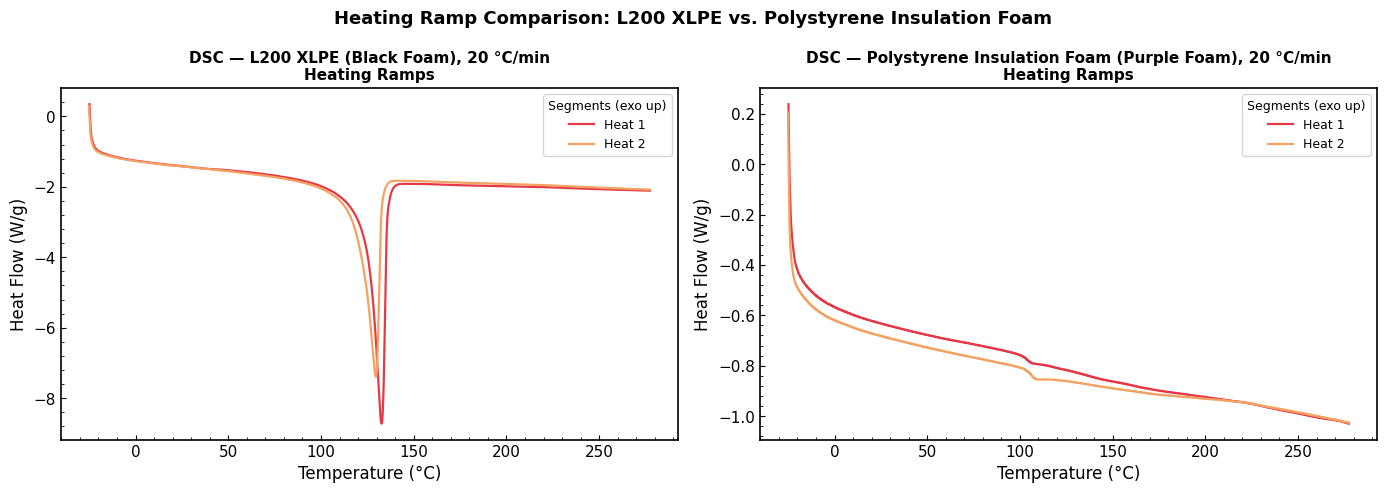

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, segs, colors, name in [
    (axes[0], segs_black,  [heat1, heat2], title1),
    (axes[1], segs_purple, [heat1, heat2], title2),
]:
    for seg_i, color, label in [(0, colors[0], 'Heat 1'), (4, colors[1], 'Heat 2')]:
        df = segs[seg_i]['df'].dropna(subset=['HeatFlow_W_g'])
        ax.plot(df['Temp_C'], df['HeatFlow_W_g'], color=color, linewidth=1.6, label=label)

    ax.set_xlabel('Temperature (°C)', fontsize=12)
    ax.set_ylabel('Heat Flow (W/g)', fontsize=12)
    ax.set_title(f'{name}\nHeating Ramps', fontsize=11, fontweight='bold')
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(5))
    ax.legend(fontsize=9, title='Segments (exo up)', title_fontsize=9)

fig.suptitle('Heating Ramp Comparison: L200 XLPE vs. Polystyrene Insulation Foam', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.savefig('Heating_comparison_DSC.png', dpi=200, bbox_inches='tight')
plt.show()


## Cooling Comparison Plot

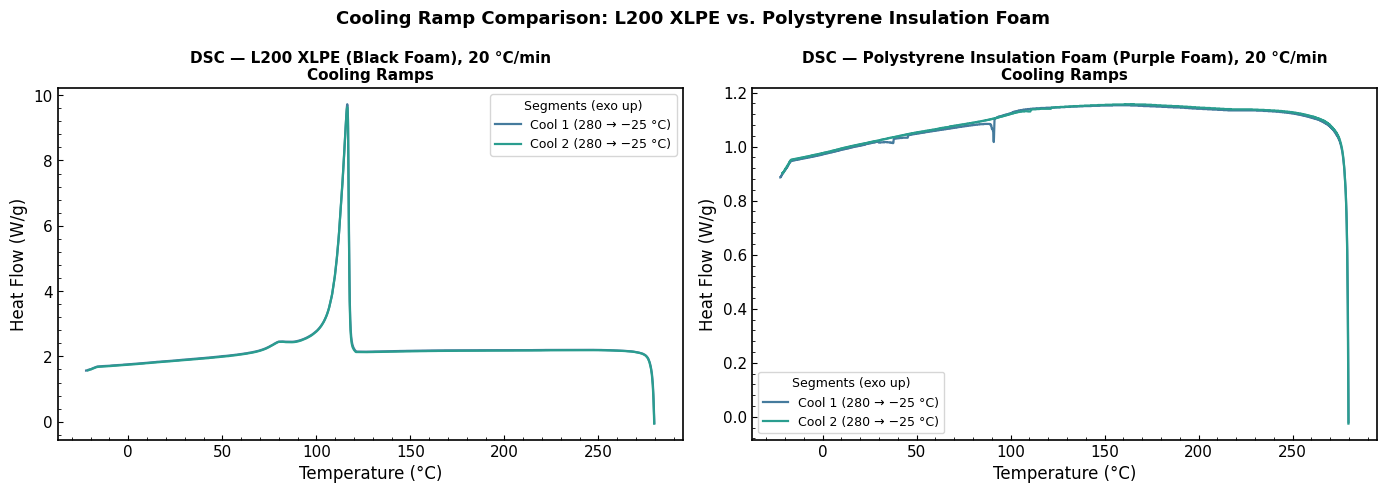

In [ ]:
# ── Cooling Ramp Comparison: Black vs. Purple Foam ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

COOL_SEGS   = [2, 6]
COOL_LABELS = ['Cool 1 (280 → −25 °C)', 'Cool 2 (280 → −25 °C)']

for ax, segs, colors, name in [
    (axes[0], segs_black,  [cool1, cool2], title1),
    (axes[1], segs_purple, [cool1, cool2], title2),
]:
    for seg_i, color, label in zip(COOL_SEGS, colors, COOL_LABELS):
        df = segs[seg_i]['df'].dropna(subset=['HeatFlow_W_g'])
        ax.plot(df['Temp_C'], df['HeatFlow_W_g'], color=color, linewidth=1.6, label=label)

    ax.set_xlabel('Temperature (°C)', fontsize=12)
    ax.set_ylabel('Heat Flow (W/g)', fontsize=12)
    ax.set_title(f'{name}\nCooling Ramps', fontsize=11, fontweight='bold')
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(5))
    ax.legend(fontsize=9, title='Segments (exo up)', title_fontsize=9)

fig.suptitle('Cooling Ramp Comparison: L200 XLPE vs. Polystyrene Insulation Foam',
             fontsize=13, fontweight='bold')
fig.tight_layout()
plt.savefig('Cooling_comparison_DSC.png', dpi=200, bbox_inches='tight')
plt.show()

## Quantitative Analysis


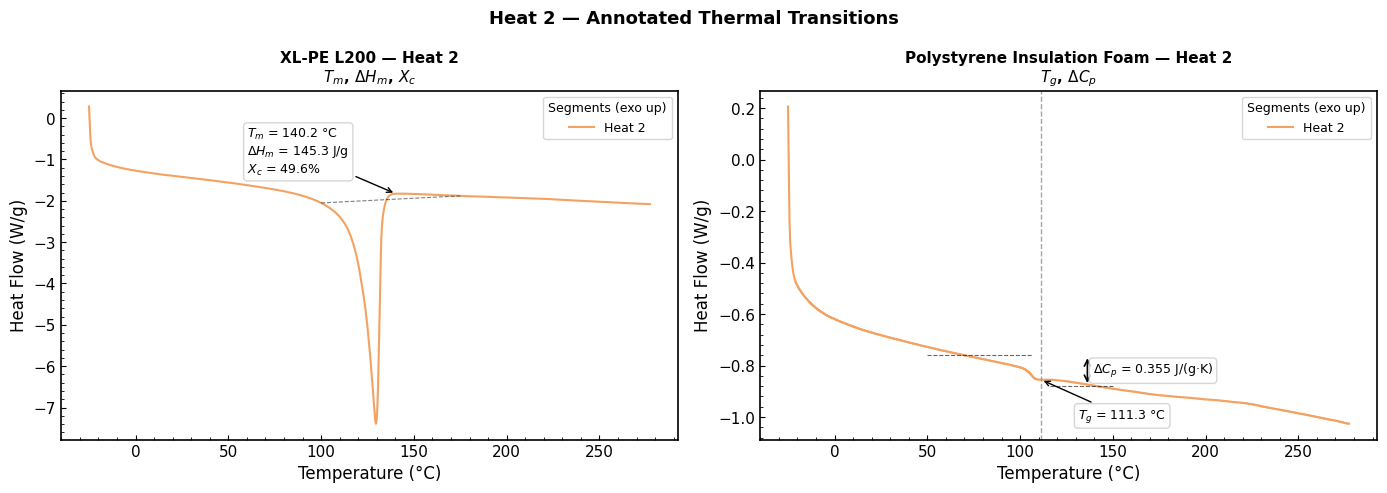

In [ ]:
# ── Summary plot: annotated Heat 2 curves ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── XL-PE — T_m annotation + baseline ───────────────────────────────────────
ax = axes[0]
df = segs_black[4]['df'].dropna(subset=['HeatFlow_W_g'])
ax.plot(df['Temp_C'], df['HeatFlow_W_g'], color=heat2, linewidth=1.5, label='Heat 2')

t_win, hf_corr = subtract_baseline(df['Temp_C'].values, df['HeatFlow_W_g'].values, 100, 175)
hf_smooth = savgol_filter(hf_corr, 51, 3)
tm_idx   = np.argmax(hf_smooth)
t_m_val  = t_win[tm_idx]
hf_m_val = df.loc[df['Temp_C'].between(t_m_val - 0.5, t_m_val + 0.5), 'HeatFlow_W_g'].mean()
dHm_val  = trapezoid(hf_corr, t_win) / beta
xc_val   = abs(dHm_val) / DHm0_PE * 100

baseline_hf = np.interp(t_win,
                         [t_win[0], t_win[-1]],
                         [df.loc[df['Temp_C'].between(t_win[0]-0.5, t_win[0]+0.5), 'HeatFlow_W_g'].mean(),
                          df.loc[df['Temp_C'].between(t_win[-1]-0.5, t_win[-1]+0.5), 'HeatFlow_W_g'].mean()])
ax.plot(t_win, baseline_hf, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

ax.annotate(f'$T_m$ = {t_m_val:.1f} °C\n$\\Delta H_m$ = {abs(dHm_val):.1f} J/g\n$X_c$ = {xc_val:.1f}%',
            xy=(t_m_val, hf_m_val), xytext=(t_m_val - 80, hf_m_val + 0.5),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#cccccc', alpha=0.8))

ax.set_xlabel('Temperature (°C)', fontsize=12)
ax.set_ylabel('Heat Flow (W/g)', fontsize=12)
ax.set_title('XL-PE L200 — Heat 2\n$T_m$, $\\Delta H_m$, $X_c$', fontsize=11, fontweight='bold')
ax.legend(fontsize=9, title='Segments (exo up)', title_fontsize=9)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(5))
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(5))

# ── PS — T_g annotation + ΔCp horizontal lines ───────────────────────────────
ax = axes[1]
df = segs_purple[4]['df'].dropna(subset=['HeatFlow_W_g'])
ax.plot(df['Temp_C'], df['HeatFlow_W_g'], color=heat2, linewidth=1.5, label='Heat 2')

mask      = (df['Temp_C'] > 50) & (df['Temp_C'] < 150)
t_sub     = df['Temp_C'].values[mask]
hf_sub    = df['HeatFlow_W_g'].values[mask]
hf_smooth = savgol_filter(hf_sub, 101, 3)
tg_val    = t_sub[np.argmax(np.gradient(hf_smooth, t_sub))]
hf_tg_val = df.loc[df['Temp_C'].between(tg_val - 0.5, tg_val + 0.5), 'HeatFlow_W_g'].mean()

pre_hf   = hf_smooth[t_sub < tg_val - 20].mean()
post_hf  = hf_smooth[t_sub > tg_val + 20].mean()
dcp_val  = abs((post_hf - pre_hf) / beta)

t_pre_start  = t_sub[t_sub < tg_val - 20][0]
t_pre_end    = tg_val - 5
t_post_start = tg_val + 5
t_post_end   = t_sub[t_sub > tg_val + 20][-1]

ax.hlines(pre_hf,  t_pre_start,  t_pre_end,  colors='black', linewidth=0.8, linestyle='--', alpha=0.6)
ax.hlines(post_hf, t_post_start, t_post_end, colors='black', linewidth=0.8, linestyle='--', alpha=0.6)
ax.annotate('', xy=(tg_val + 25, post_hf), xytext=(tg_val + 25, pre_hf),
            arrowprops=dict(arrowstyle='<->', color='black', lw=1.2))
ax.text(tg_val + 28, (pre_hf + post_hf) / 2,
        f'$\\Delta C_p$ = {dcp_val:.3f} J/(g·K)', fontsize=9, va='center',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#cccccc', alpha=0.8))

ax.axvline(tg_val, color='grey', linestyle='--', linewidth=1, alpha=0.7)
ax.annotate(f'$T_g$ = {tg_val:.1f} °C',
            xy=(tg_val, hf_tg_val), xytext=(tg_val + 20, hf_tg_val - 0.15),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#cccccc', alpha=0.8))

ax.set_xlabel('Temperature (°C)', fontsize=12)
ax.set_ylabel('Heat Flow (W/g)', fontsize=12)
ax.set_title('Polystyrene Insulation Foam — Heat 2\n$T_g$, $\\Delta C_p$', fontsize=11, fontweight='bold')
ax.legend(fontsize=9, title='Segments (exo up)', title_fontsize=9)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(5))
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(5))

fig.suptitle('Heat 2 — Annotated Thermal Transitions', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.savefig('DSC_annotated_Heat2.png', dpi=200, bbox_inches='tight')
plt.show()

XL-PE L200 (Black Dense Foam) — Crystallization

  Cool 2
    T_c (peak)              = 116.5 °C
    ΔH_c (exotherm)         = 151.5 J/g
    X_c (from cooling)      = 51.7%
    (ref: ΔH°_m(PE) = 293 J/g)

Polystyrene Insulation Foam (Purple) — T_g Cooling

  Cool 2
    T_g (cooling, midpoint) = 109.0 °C


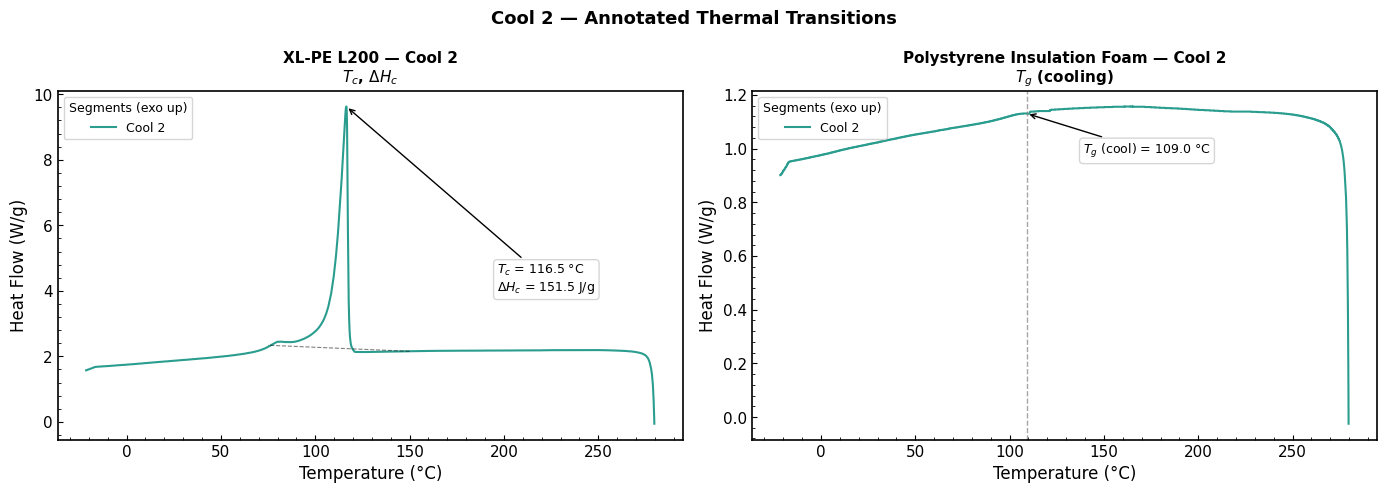

In [ ]:
# ── Cool 2 — Annotated Thermal Transitions ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── XL-PE — T_c annotation + baseline ───────────────────────────────────────
ax = axes[0]
df = segs_black[6]['df'].dropna(subset=['HeatFlow_W_g'])
ax.plot(df['Temp_C'], df['HeatFlow_W_g'], color=cool2, linewidth=1.5, label='Cool 2')

t  = df['Temp_C'].values
hf = df['HeatFlow_W_g'].values
mask    = (t >= 75) & (t <= 150)
t_win   = t[mask]; hf_win = hf[mask]

hf_left  = hf[(t >= 147) & (t <= 150)].mean()
hf_right = hf[(t >= 75)  & (t <= 78)].mean()
baseline_hf = np.linspace(hf_left, hf_right, len(t_win))
hf_corr = hf_win - baseline_hf

tc_idx   = np.argmax(savgol_filter(hf_win, 51, 3))
t_c_val  = t_win[tc_idx]
hf_c_val = hf[np.argmin(np.abs(t - t_c_val))]
dHc_val  = trapezoid(hf_corr[::-1], t_win[::-1]) / beta
xc_cool  = abs(dHc_val) / DHm0_PE * 100

ax.plot(t_win, baseline_hf, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.annotate(f'$T_c$ = {t_c_val:.1f} °C\n$\\Delta H_c$ = {dHc_val:.1f} J/g',
            xy=(t_c_val, hf_c_val), xytext=(t_c_val + 80, 4.0),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#cccccc', alpha=0.8))

ax.set_xlabel('Temperature (°C)', fontsize=12)
ax.set_ylabel('Heat Flow (W/g)', fontsize=12)
ax.set_title('XL-PE L200 — Cool 2\n$T_c$, $\\Delta H_c$', fontsize=11, fontweight='bold')
ax.legend(fontsize=9, title='Segments (exo up)', title_fontsize=9)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(5))
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(5))

print('=' * 55)
print('XL-PE L200 (Black Dense Foam) — Crystallization')
print('=' * 55)
print(f'\n  Cool 2')
print(f'    T_c (peak)              = {t_c_val:.1f} °C')
print(f'    ΔH_c (exotherm)         = {dHc_val:.1f} J/g')
print(f'    X_c (from cooling)      = {xc_cool:.1f}%')
print(f'    (ref: ΔH°_m(PE) = {DHm0_PE} J/g)')

# ── PS — T_g annotation on cooling ──────────────────────────────────────────
ax = axes[1]
df = segs_purple[6]['df'].dropna(subset=['HeatFlow_W_g'])
ax.plot(df['Temp_C'], df['HeatFlow_W_g'], color=cool2, linewidth=1.5, label='Cool 2')

mask        = (df['Temp_C'] > 50) & (df['Temp_C'] < 150)
t_sub       = df['Temp_C'].values[mask]
hf_sub      = df['HeatFlow_W_g'].values[mask]
hf_smooth   = savgol_filter(hf_sub, 101, 3)
dhf         = np.gradient(hf_smooth, t_sub)
tg_cool_val = t_sub[np.argmin(dhf)]
hf_tg_val   = df.loc[df['Temp_C'].between(tg_cool_val - 0.5, tg_cool_val + 0.5), 'HeatFlow_W_g'].mean()

ax.axvline(tg_cool_val, color='grey', linestyle='--', linewidth=1, alpha=0.7)
ax.annotate(f'$T_g$ (cool) = {tg_cool_val:.1f} °C',
            xy=(tg_cool_val, hf_tg_val), xytext=(tg_cool_val + 30, hf_tg_val - 0.15),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#cccccc', alpha=0.8))

ax.set_xlabel('Temperature (°C)', fontsize=12)
ax.set_ylabel('Heat Flow (W/g)', fontsize=12)
ax.set_title('Polystyrene Insulation Foam — Cool 2\n$T_g$ (cooling)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9, title='Segments (exo up)', title_fontsize=9)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(5))
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(5))

print()
print('=' * 55)
print('Polystyrene Insulation Foam (Purple) — T_g Cooling')
print('=' * 55)
print(f'\n  Cool 2')
print(f'    T_g (cooling, midpoint) = {tg_cool_val:.1f} °C')

fig.suptitle('Cool 2 — Annotated Thermal Transitions', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.savefig('DSC_annotated_Cool2.png', dpi=200, bbox_inches='tight')
plt.show()